# Rheology (REHO)

In [57]:
"""Tool to plot infer some analysis on DSC thermograms"""
from dataclasses import dataclass, field
from os import listdir
import matplotlib.pyplot as plt
from pandas import DataFrame, read_csv, concat
from sklearn.linear_model import LinearRegression
# 
import numpy as np
from scipy import sparse
from scipy.sparse.linalg import spsolve

In [58]:
# Global variables
PLOT_SINGLE_DATA = False
PLOT_M_SD = True

@dataclass
class Measurment:
    """Class to represent a measurment"""
    filename: str
    data: DataFrame = field(init=False)
    def __post_init__(self):
        self.data = read_csv(self.filename, skiprows=7, encoding='utf-16', sep='\t')

    def clean(self, **kwargs):
        """Remove all rows with NaN"""
        #self.data = self.data.dropna()
        # keep only the column Temperature and Heat Flow
        self.data = self.data[["Shear Strain","Storage Modulus", "Loss Modulus"]]
        # drop first 2 rows
        self.data = self.data.iloc[2:]
        self.data = self.data.astype(float)
        # use shear strain as index





def PlotterSingle(namedir, N, **kwargs):

    measurments = []
    exp = DataFrame()
    for filename in listdir(namedir):
        measurments.append(Measurment(namedir+"/"+filename))
        measurments[-1].clean(**kwargs)
        exp = concat([exp, measurments[-1].data], axis=1)
        exp = exp.dropna()

        if PLOT_SINGLE_DATA:

            x = [a*100 for a in measurments[-1].data["Shear Strain"]]
            y_SM = [a for a in measurments[-1].data["Storage Modulus"]]
            y_LM = [a for a in measurments[-1].data["Loss Modulus"]]
            # triangles for y_SM
            plt.loglog(x, y_SM, marker="s", markersize=5)#, label = "Storage Modulus") 
            # squares for y_LM
            plt.loglog(x, y_LM, marker="^", markersize=5)#, label = "Loss Modulus")


    # addto legend that the triangles are for storage modulus and the squares for loss modulus
    if PLOT_SINGLE_DATA:
        plt.loglog([], [], marker="s", markersize=5, label = "Storage Modulus : "+r"$G^{\prime}$", color = "black")
        plt.loglog([], [], marker="^", markersize=5, label = "Loss Modulus : "+r"$G^{\prime\prime}$", color = "black")
    
    if PLOT_M_SD:
        # multiply the shear strain by 100 to get the percentage
        exp["Shear Strain"] = exp["Shear Strain"]*100
        # print first relative difference of exp w.r.t Storage Modulus
        # take the mean over all the columns with the same name 
        mean = exp.groupby(exp.columns, axis=1).mean()
        std = exp.groupby(exp.columns, axis=1).std()
        x = [a for a in mean["Shear Strain"]]
        y_LM = [a for a in mean["Loss Modulus"]]
        y_SM = [a for a in mean["Storage Modulus"]]

        pct_list = mean.pct_change()
        pct = pct_list.replace(np.nan, 0)
        pct_list = pct.abs()
        pct = pct_list[pct_list["Storage Modulus"] < 0.05]
        l = len(pct)+1
        tau = mean["Shear Strain"].iloc[l]

        plt.fill_between([0, tau], 0, 1000000, color="gray",
                         alpha=0.2, label="LVE limit : $|G^{\prime}|$ < 5 %")

        # maxstrain = pct["Shear Strain"].max()
        plt.axvline(x=tau, color='black', linestyle='--', alpha = 0.2)
        
        limit_LVE = mean["Storage Modulus"].iloc[:l].mean()
        plt.axhline(y=limit_LVE, color='red', alpha = 0.5, label = r"$G^{\prime}$"+" = "+str(round(limit_LVE, 2))+" Pa")
        
        # fill the area between the vertical line and the right border of the plot


        # add the text "plastic deformation" between the vertical line and the right border of the plot
        plt.text(tau+0.1, 150, "plastic deformation", fontsize=12, verticalalignment='center')
        # on the other side of the vertical line, add the text "elastic deformation"
        plt.text(1/1000, 150, "elastic deformation", fontsize=12, verticalalignment='center')
        # add the value of tau on the vertical axis with 3rd decimal
        plt.text(tau, 1000, str(round(tau, 5)), fontsize=12, verticalalignment='center',rotation=90)

        plt.loglog(x, y_SM ,linewidth=1.5, label = "Storage Modulus : "+r"$G^{\prime}$", marker="s", markersize=5)
        plt.loglog(x, y_LM ,linewidth=1.5, label = "Loss Modulus : "+r"$G^{\prime\prime}$", marker="^", markersize=5)

        plt.fill_between(mean["Shear Strain"], mean["Storage Modulus"]-std["Storage Modulus"], mean["Storage Modulus"]+std["Storage Modulus"], alpha=0.5)
        plt.fill_between(mean["Shear Strain"], mean["Loss Modulus"]-std["Loss Modulus"], mean["Loss Modulus"]+std["Loss Modulus"], alpha=0.5)

        # add constant line for LVE limit

       
        # from pct extract value of Shear Strain where the maximum of Storage Modulus is less than 0.05  


    plt.xlabel("Shear Strain in $\gamma$ in %")
    plt.ylabel("Modulus [Pa]")

    plt.title("Amplitude sweep oleogel RBX/RSO " +
              str(N)+"% ")
    

    mean = exp.mean(axis=1)
    #mean.plot(color="black", legend=False, linewidth=1.5, figsize=(10, 5), label = "mean")
    plt.grid()
    #std = exp.std(axis=1)
    #plt.fill_between(mean.index, mean-std, mean+std, color="C0", alpha=0.5, label = "std")

    plt.tight_layout()
    # on the y axis, the values  for 100, 1000, 10000, 100000, 1000000, 10000000 in scientific notation
    plt.yticks([100, 1000, 10000, 100000, 1000000], [r"$10^2$", r"$10^3$", r"$10^4$", r"$10^5$", r"$10^6$"])
    plt.xticks([0.001, 0.01, 0.1, 1, 10], [r"$0.001$", r"$0.01$", r"$0.1$", r"$1$", r"$10$"])
    plt.legend(loc = "upper right")
    #plt.show()
    

    #plt.legend(["mean", "std"])
    #plt.savefig(namedir+".png", dpi=1000)



#def PlotterMultiple(namedir, displacement,cooling_or_heating,  **kwargs):
#
#    for N in [2, 4, 6, 8]:
#        namedir = str(N)+"perc"
#        measurments = []
#        exp = DataFrame()
#        for filename in listdir(namedir):
#            measurments.append(Measurment(namedir+"/"+filename))
#            measurments[-1].clean(**kwargs)
#            exp = concat([exp, measurments[-1].data], axis=1)
#            exp = exp.dropna()
#
#        exp = exp+displacement*(N/2-1)
#
#        # exp.plot(color = "gray", legend = False, alpha = 0.5, linewidth = 0.1, figsize=(10, 5))
#        mean = exp.mean(axis=1)
#        mean.plot(legend=False, linewidth=1, figsize=(7, 4), label=str(N)+"%")
#        std = exp.std(axis=1)
#        plt.fill_between(mean.index, mean-std, mean+std, alpha=0.5)
#
#    plt.xlabel("Temperature [°C]")
#    plt.ylabel("Heat flow endo up [mW]")
#    plt.title("DSC thermogram oleogel RBX/RSO "+cooling_or_heating)
#    plt.tight_layout()
#    plt.grid()
#    plt.legend(loc = "upper right")
#    plt.savefig(cooling_or_heating+ namedir+".png", dpiF=1000)

In [59]:
p = 0.9
lam = 10**12
niter = 10
kwargs = {"p": p, "lam": lam, "niter": niter}

PLOT_SINGLE_DATA = False
PLOT_M_SD = True

/tmp/ipykernel_32855/2993238392.py:58: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  mean = exp.groupby(exp.columns, axis=1).mean()
/tmp/ipykernel_32855/2993238392.py:59: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  std = exp.groupby(exp.columns, axis=1).std()


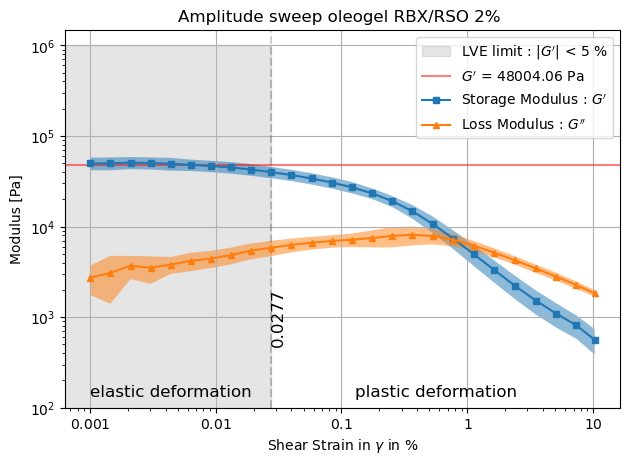

In [60]:
N = 2
namedir = str(N)+"perc"
PlotterSingle(namedir, N, **kwargs)



/tmp/ipykernel_32855/2993238392.py:58: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  mean = exp.groupby(exp.columns, axis=1).mean()
/tmp/ipykernel_32855/2993238392.py:59: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  std = exp.groupby(exp.columns, axis=1).std()


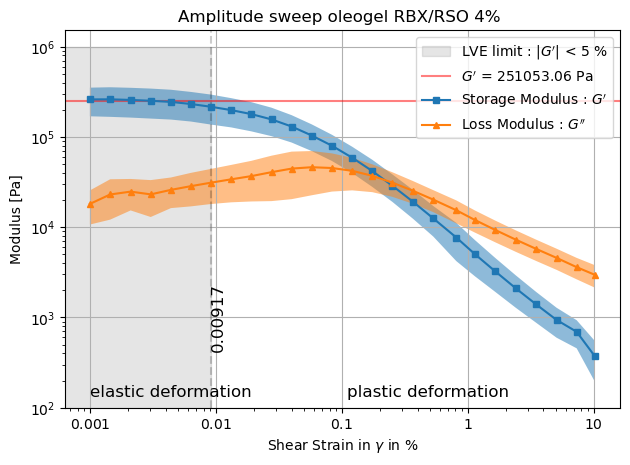

In [61]:
N = 4
namedir = str(N)+"perc"

PlotterSingle(namedir, N, **kwargs)




/tmp/ipykernel_32855/2993238392.py:58: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  mean = exp.groupby(exp.columns, axis=1).mean()
/tmp/ipykernel_32855/2993238392.py:59: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  std = exp.groupby(exp.columns, axis=1).std()


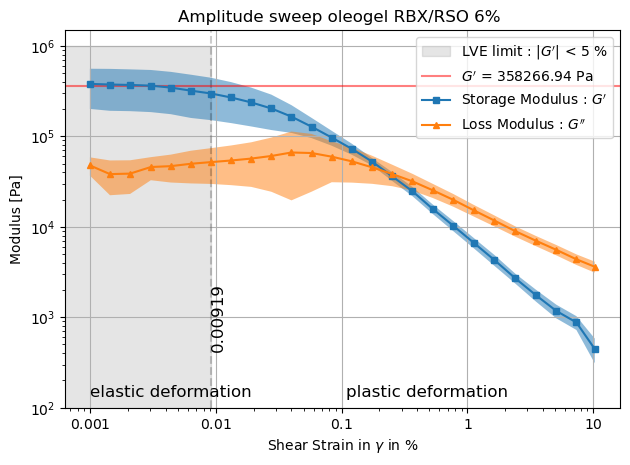

In [62]:
N = 6
namedir = str(N)+"perc"

PlotterSingle(namedir, N, **kwargs)



/tmp/ipykernel_32855/2993238392.py:58: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  mean = exp.groupby(exp.columns, axis=1).mean()
/tmp/ipykernel_32855/2993238392.py:59: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  std = exp.groupby(exp.columns, axis=1).std()


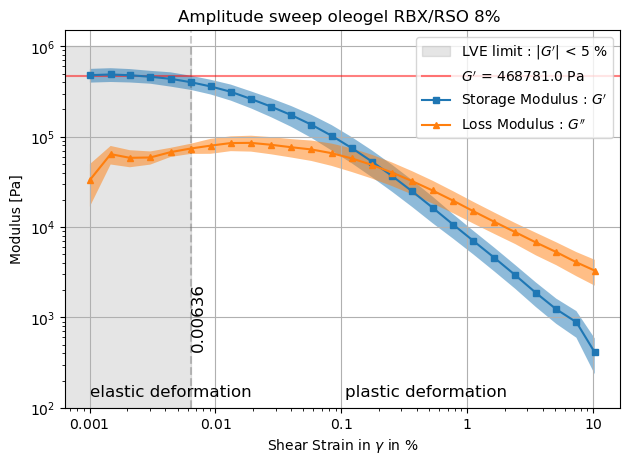

In [63]:
N = 8
namedir = str(N)+"perc"

PlotterSingle(namedir, N, **kwargs)



# Together

In [64]:
#displacement = 1
#
#PlotterMultiple(namedir, displacement, cooling_or_heating, **kwargs)
